# **8. AWS Messaging, Monitoring, Auditing, Events, and Configuration**



This section covers six important AWS services:

```text
Amazon SQS
Amazon SNS
Amazon CloudWatch
AWS CloudTrail
Amazon EventBridge
AWS Config
```

They solve different problems:

```text
SQS
=
Message Queue

SNS
=
Notifications / Pub-Sub

CloudWatch
=
Monitoring and Metrics

CloudTrail
=
API Activity Auditing

EventBridge
=
Event Routing and Automation

AWS Config
=
Resource Configuration Tracking and Compliance
```

---

## 8.1 Amazon SQS

**Amazon SQS (Simple Queue Service)** is a fully managed **message queue** service.


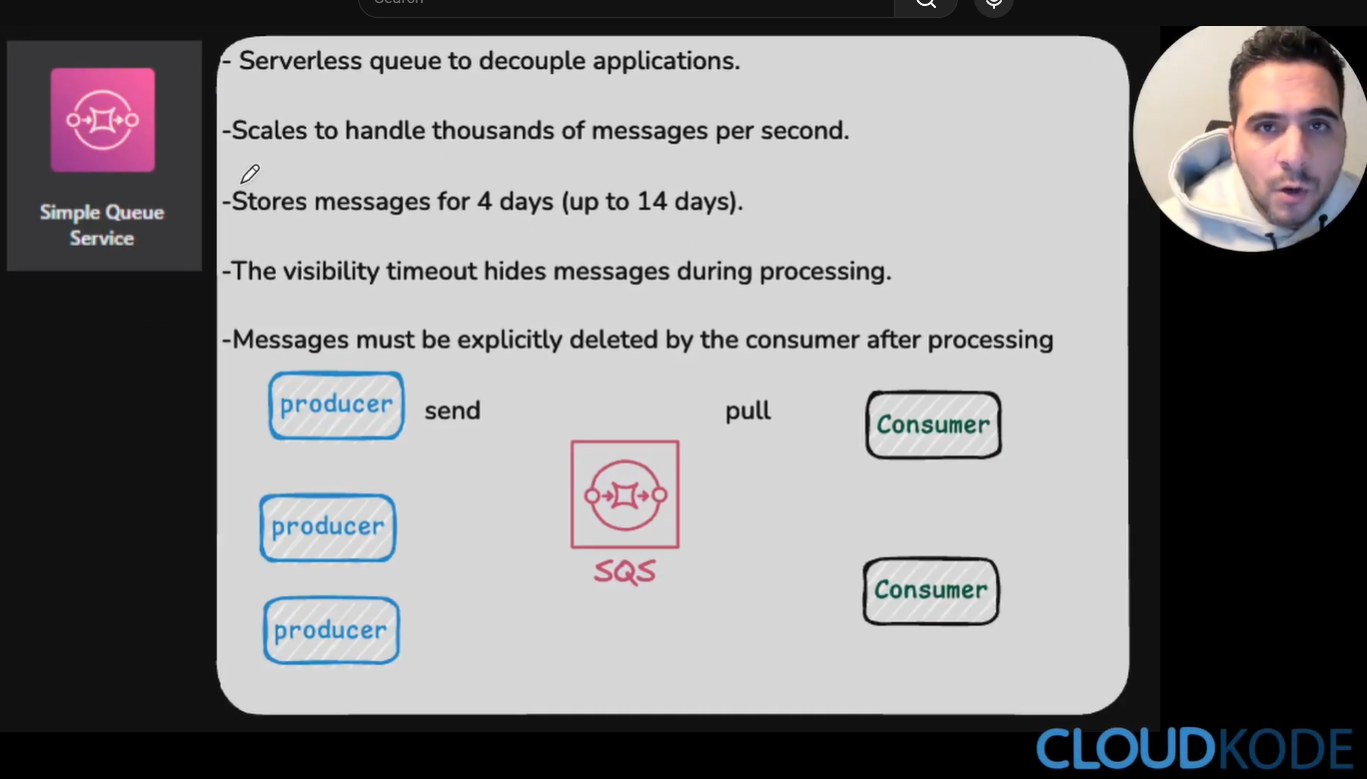


It is used to decouple application components.

Instead of:

```text
Application A
     |
     v
Application B
```

where Application B must be available immediately, we can use:

```text
Application A
     |
     v
    SQS
     |
     v
Application B
```

Application A sends a message to SQS.

Application B retrieves the message later when it is ready.

---

## 8.2 Why Use SQS?

Suppose an online store receives an order.

Without SQS:

```text
Customer
   |
Place Order
   |
Application
   |
Process Payment
   |
Generate Invoice
   |
Send Email
   |
Update Inventory
```

If one service fails, the complete request may fail.

With SQS:

```text
Customer
   |
Place Order
   |
Application
   |
   v
SQS Queue
   |
   +------> Payment Worker
   |
   +------> Order Processing Worker
```

The queue acts as a buffer between services.

---

## 8.3 SQS Producer and Consumer

SQS normally has:

```text
Producer
=
Sends messages
```

and:

```text
Consumer
=
Receives and processes messages
```

Architecture:

```text
Producer
   |
   | Send Message
   v
SQS Queue
   |
   | Receive Message
   v
Consumer
```

Example:

```text
Web Application
      |
      v
Order Queue
      |
      v
Order Processing Service
```

---

## 8.4 SQS Standard Queue

A **Standard Queue** provides very high throughput.

Characteristics:

```text
High scalability
At-least-once delivery
Best-effort ordering
```

This means a message may occasionally be delivered more than once.

Your application should therefore be designed to handle duplicate processing safely.

Example:

```text
Message 1
Message 2
Message 3

Possible processing:

Message 1
Message 3
Message 2
```

Strict ordering is not guaranteed.

---

## 8.5 SQS FIFO Queue

FIFO means:

```text
First In, First Out
```

A FIFO queue is designed when order matters.

Example:

```text
Message 1
Message 2
Message 3
```

Processing order:

```text
Message 1
   ↓
Message 2
   ↓
Message 3
```

FIFO queues also provide mechanisms for preventing duplicate message processing.

Use FIFO when:

```text
Message order matters
Duplicate processing must be controlled
```

---

## 8.6 SQS Visibility Timeout

When a consumer receives a message, SQS temporarily hides it from other consumers.

This period is called:

```text
Visibility Timeout
```

Example:

```text
Queue
  |
Consumer receives Message A
  |
Message A becomes temporarily invisible
  |
Consumer processes Message A
```

If processing succeeds:

```text
Consumer
   |
Delete Message
   |
Message removed
```

If the consumer fails before deleting the message:

```text
Visibility Timeout expires
        |
        v
Message becomes visible again
```

Another consumer can then process it.

---

## 8.7 SQS Dead-Letter Queue

A **Dead-Letter Queue (DLQ)** stores messages that repeatedly fail processing.

Example:

```text
Main Queue
   |
Message
   |
Processing Failed
   |
Retry
   |
Processing Failed Again
   |
   v
Dead-Letter Queue
```

This prevents problematic messages from blocking normal processing.

You can later inspect the failed messages.

---

## 8.8 SQS Example

Consider an image processing system.

```text
User
 |
Uploads Image
 |
Application
 |
SQS Queue
 |
Image Processing Workers
 |
Processed Image
```

If 10,000 images arrive suddenly, the queue can hold the messages while workers process them gradually.

This helps absorb traffic spikes.

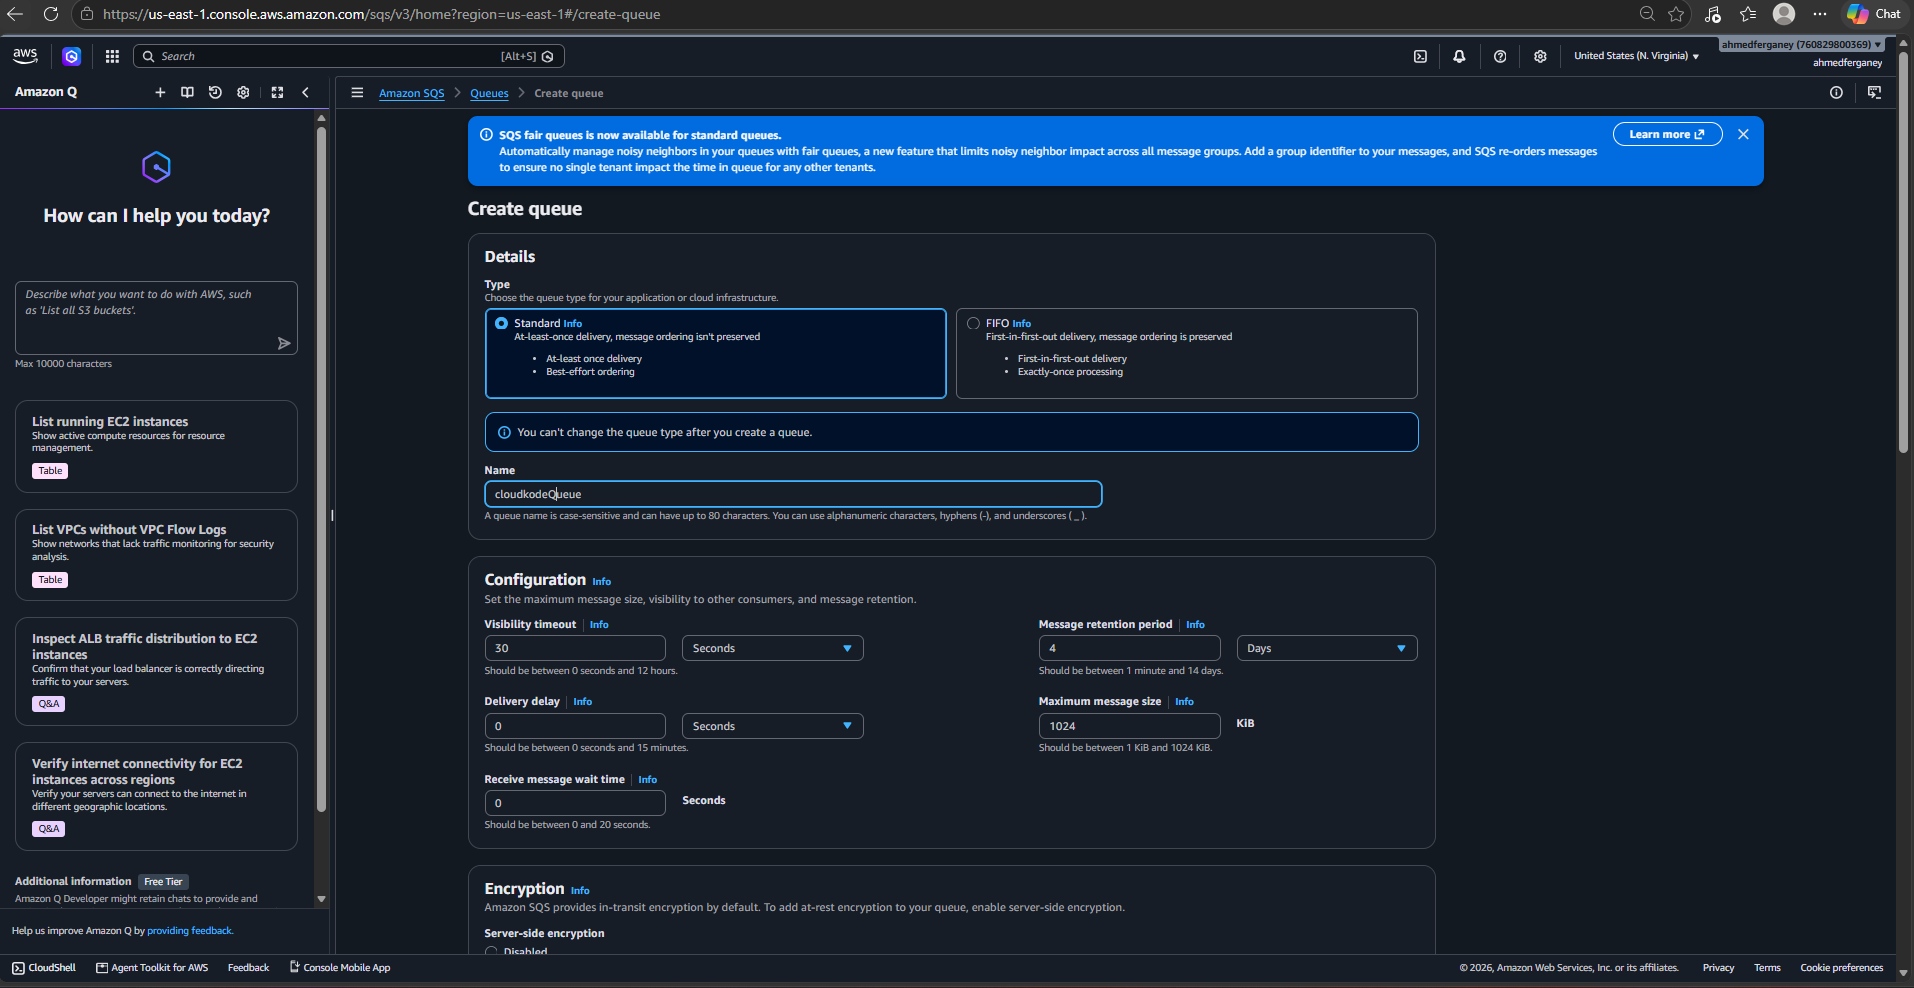

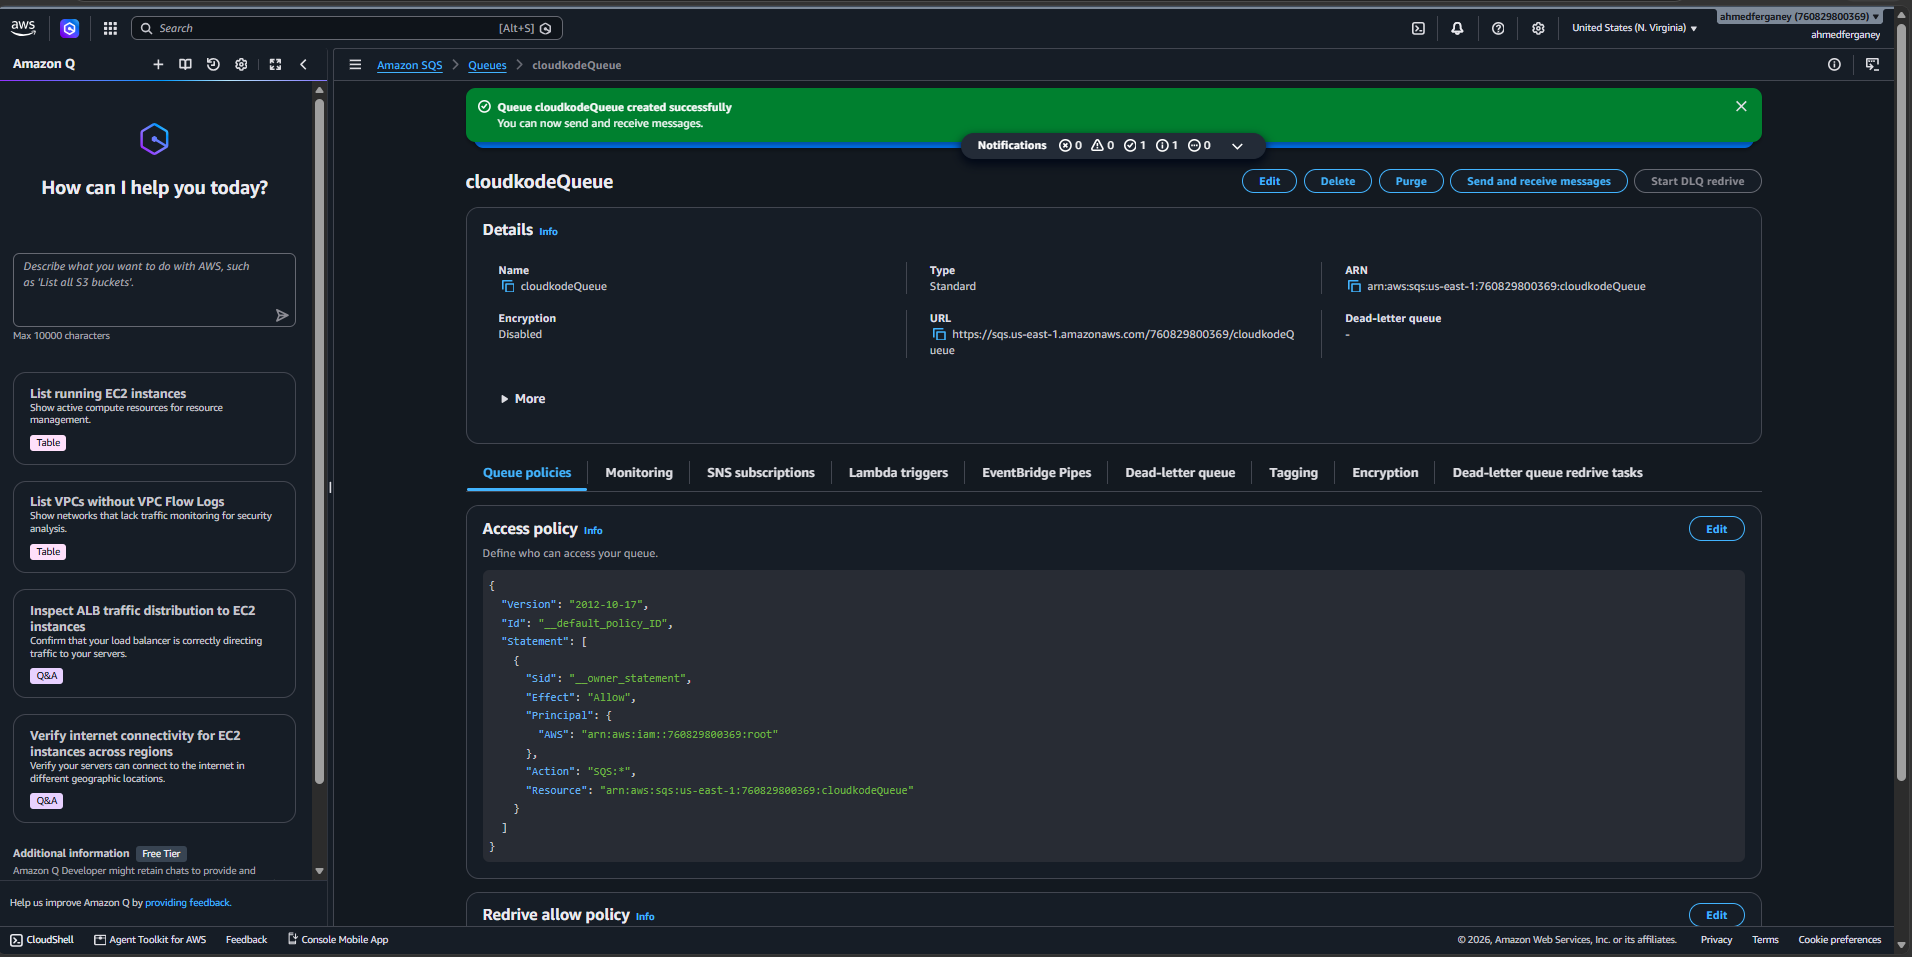

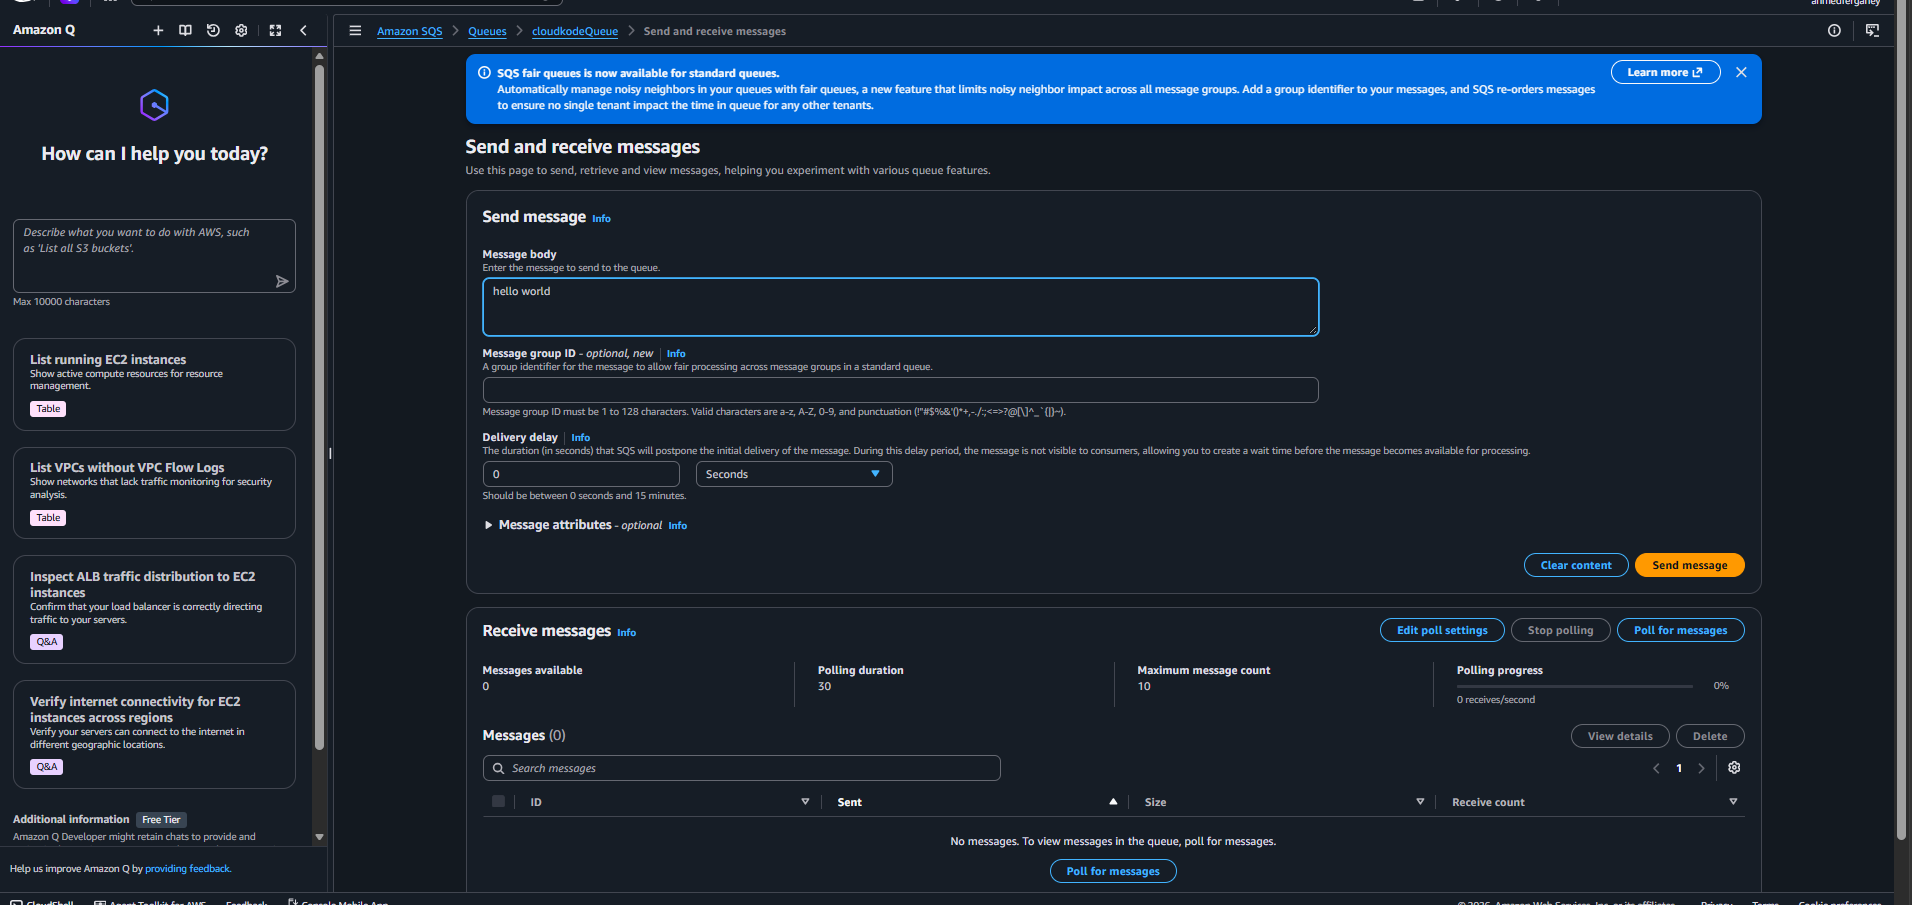

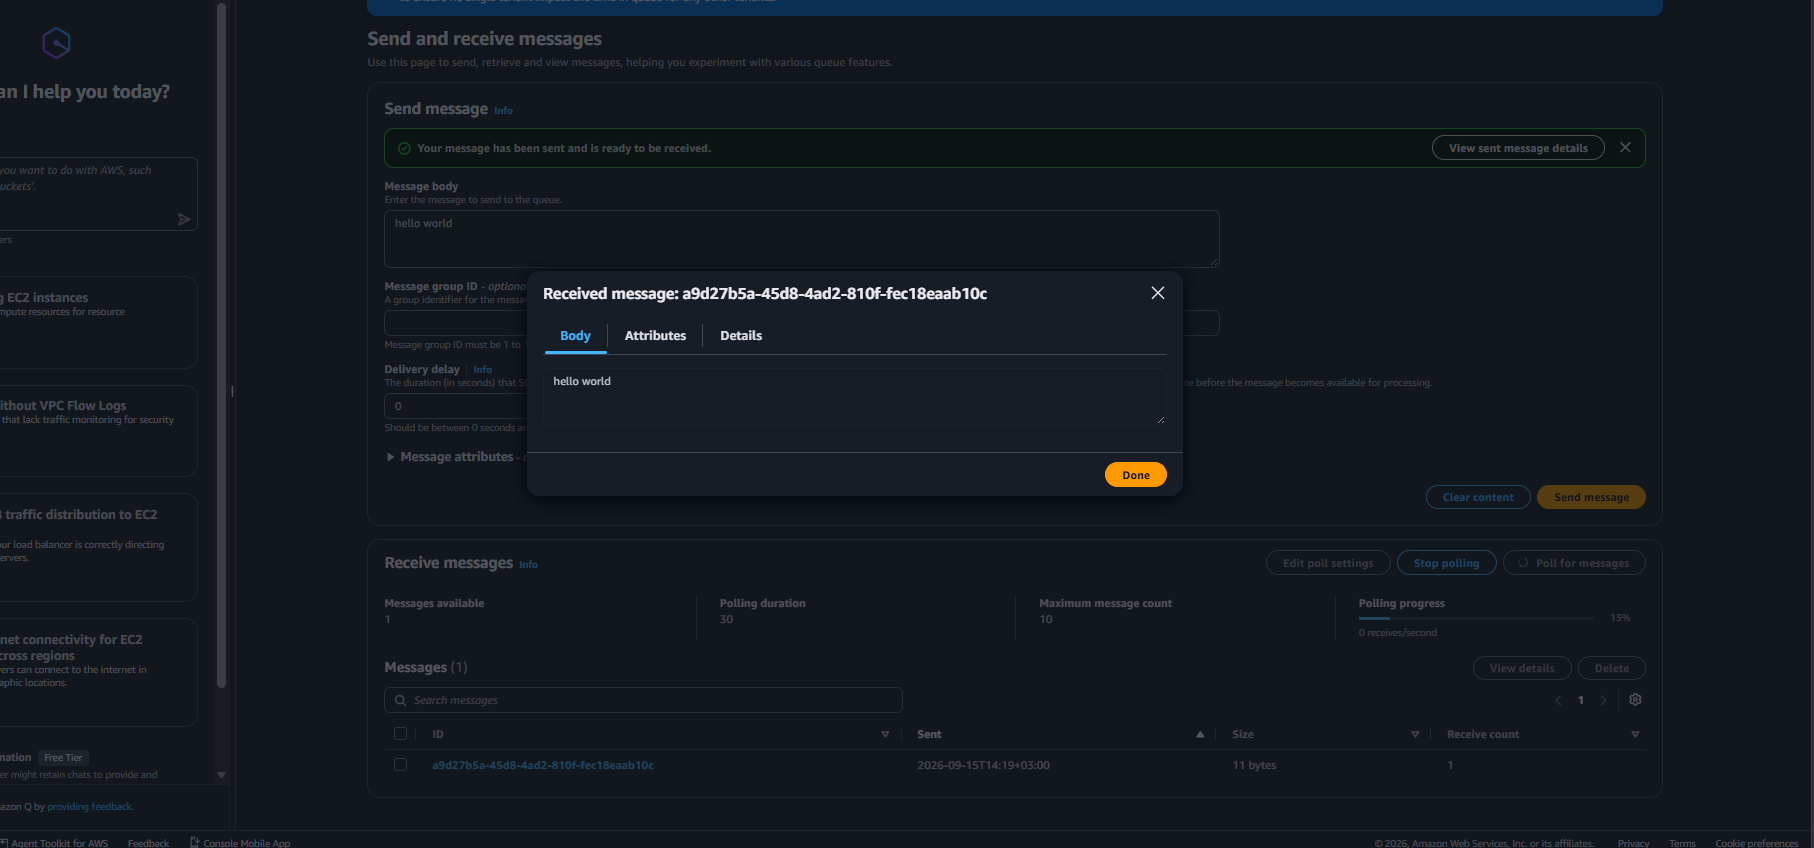

---

# 8.9 Amazon SNS

**Amazon SNS (Simple Notification Service)** is a fully managed **publish/subscribe messaging service**.

SNS is useful when one message should be delivered to multiple subscribers.


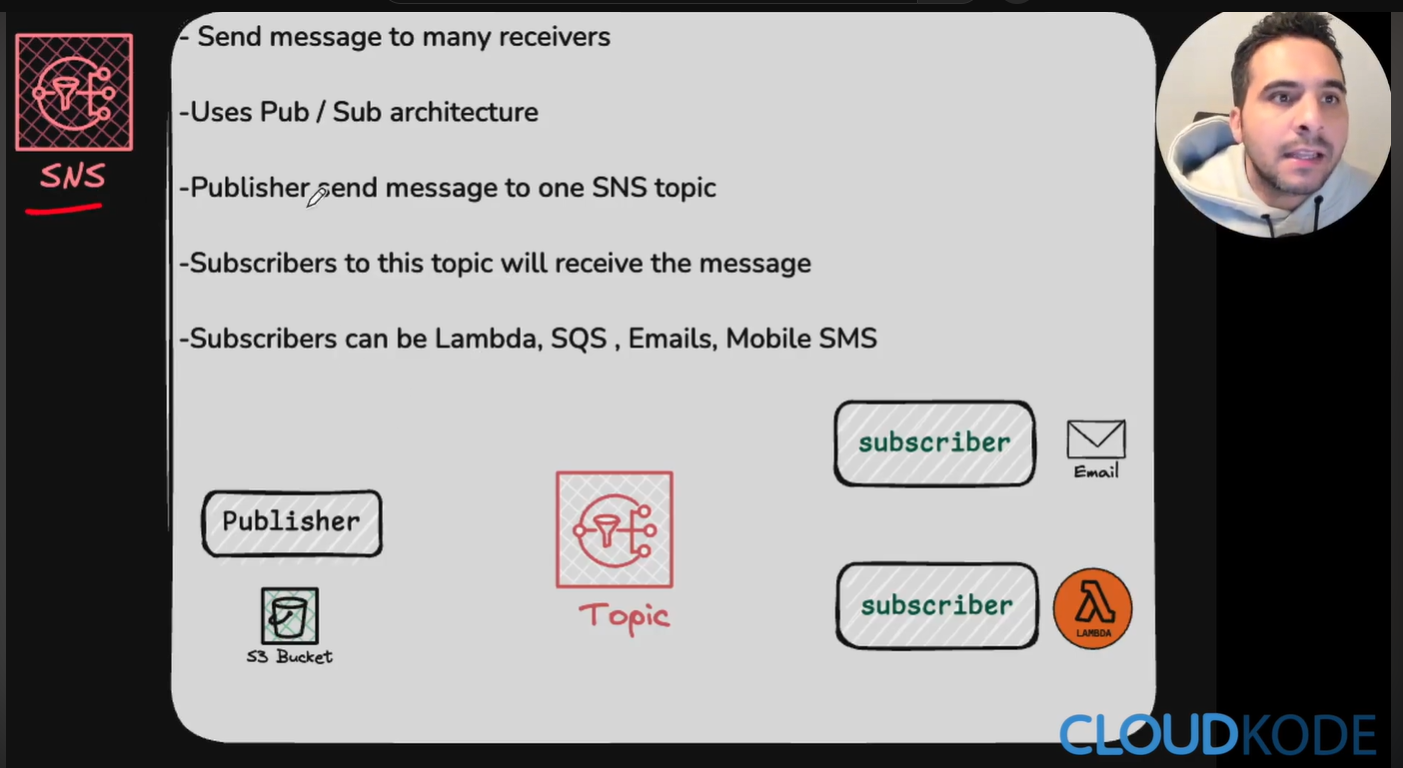

Architecture:

```text
Publisher
    |
    v
SNS Topic
    |
    +------> Email
    |
    +------> SMS
    |
    +------> Lambda
    |
    +------> SQS
```

---

## 8.10 SNS Topic

Applications publish messages to an:

```text
SNS Topic
```

Subscribers subscribe to that topic.

Example:

```text
Application
    |
    | Publish
    v
OrderEvents Topic
    |
    +----> Email Notification
    |
    +----> SQS Queue
    |
    +----> Lambda
```

One published message can therefore be delivered to many destinations.


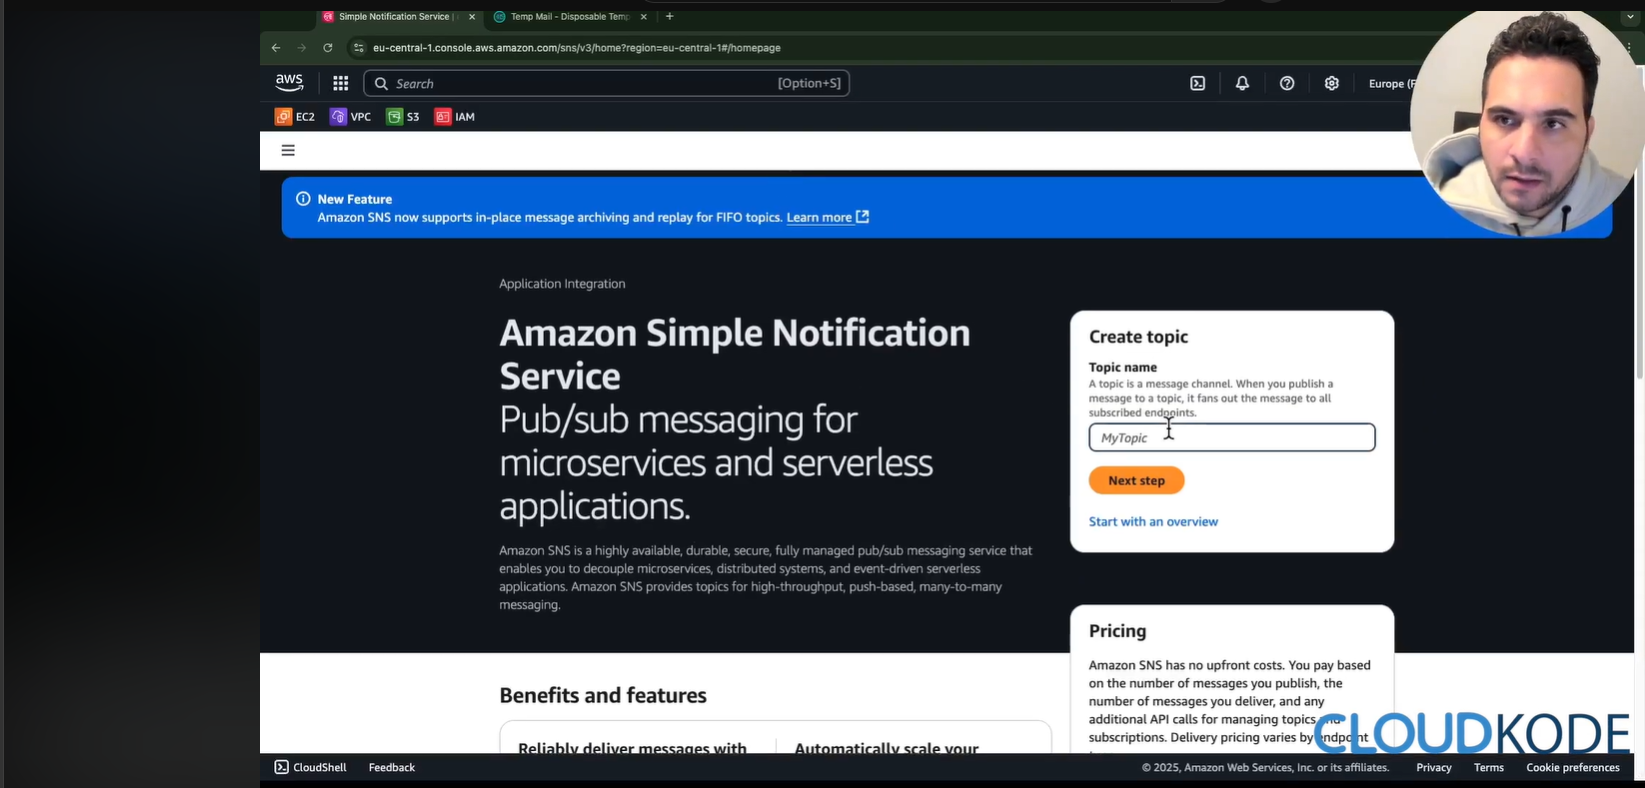

---

## 8.11 SNS Publisher and Subscribers

SNS uses a one-to-many pattern.

```text
Publisher
   |
   v
SNS Topic
   |
   +------> Subscriber A
   |
   +------> Subscriber B
   |
   +------> Subscriber C
```

This is called:

```text
Pub/Sub
```

which means:

```text
Publish / Subscribe
```

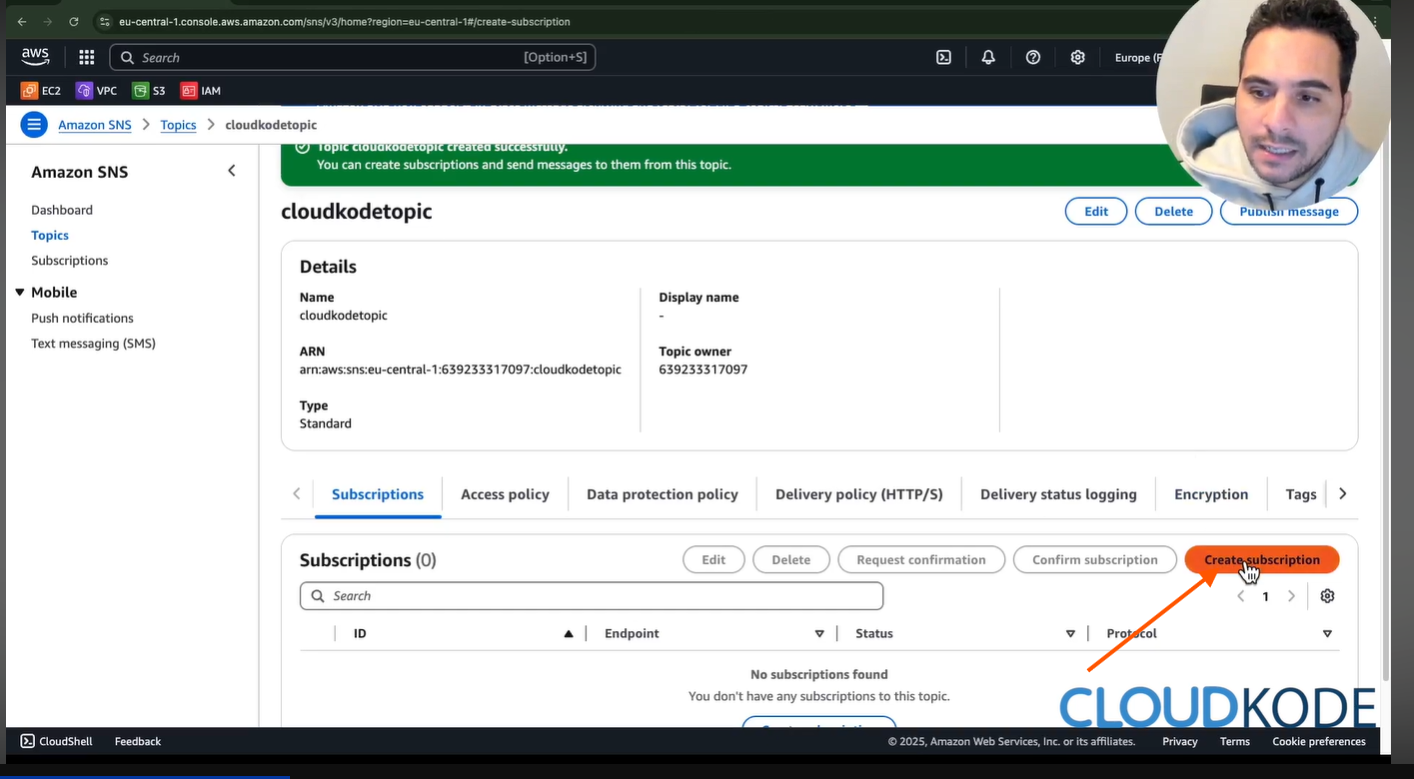

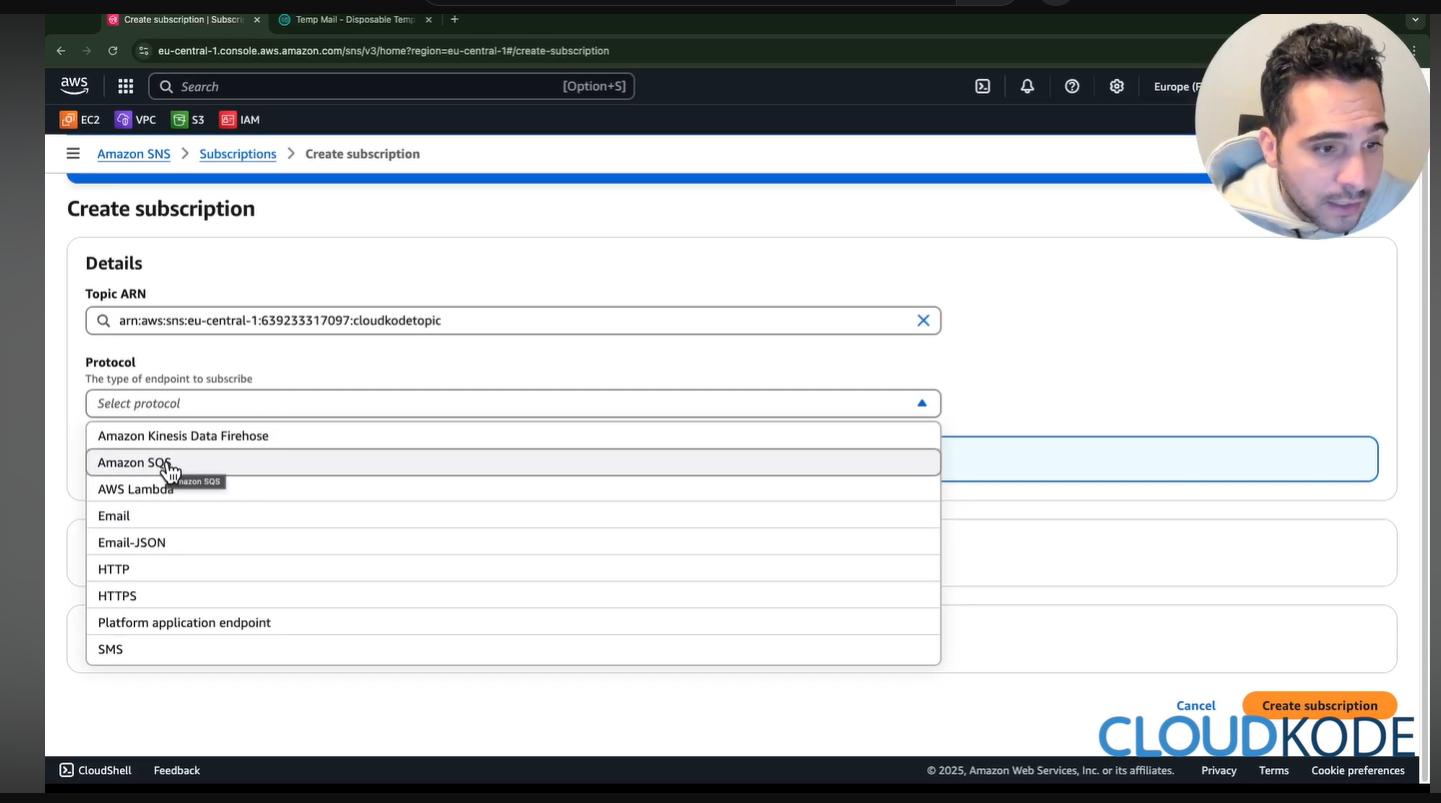

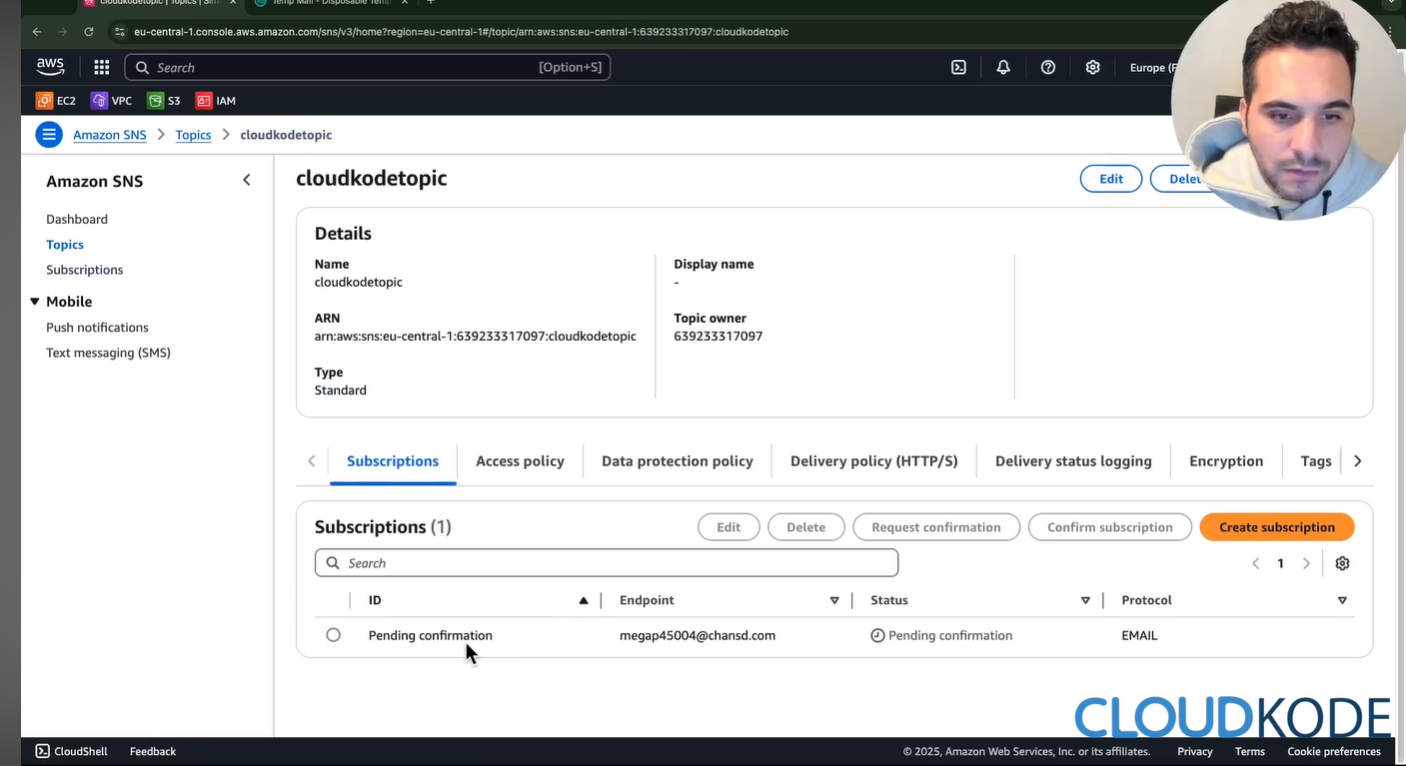

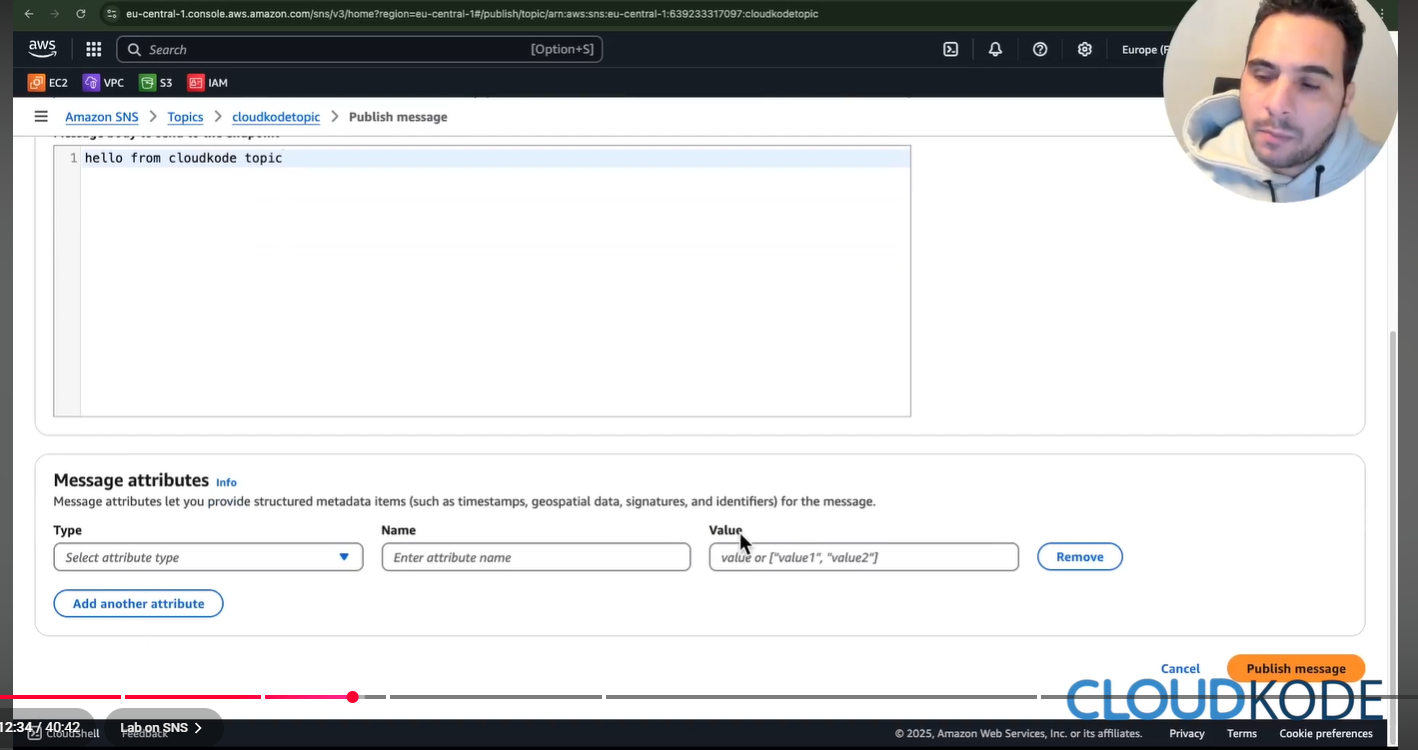

---

## 8.12 SNS Use Case

Suppose a monitoring system detects a critical server problem.

```text
CloudWatch Alarm
      |
      v
SNS Topic
      |
      +------> Email Administrator
      |
      +------> SMS Administrator
      |
      +------> Lambda
```

One alert can notify multiple destinations.

---

# 8.13 SQS vs SNS

The core difference is:

```text
SQS
=
Queue
=
Consumer pulls messages
```

while:

```text
SNS
=
Pub/Sub
=
Pushes messages to subscribers
```

Example SQS:

```text
Producer
   |
   v
Queue
   |
   v
Consumer
```

Example SNS:

```text
Publisher
   |
   v
SNS Topic
   |
   +------> Subscriber 1
   |
   +------> Subscriber 2
   |
   +------> Subscriber 3
```

---

## 8.14 SNS + SQS Fan-Out Pattern

SNS and SQS are often used together.

Example:

```text
Application
     |
     v
SNS Topic
     |
     +------> SQS Queue A
     |
     +------> SQS Queue B
     |
     +------> SQS Queue C
```

Each queue receives a copy of the event.

Different applications can then process the event independently.

For example:

```text
Order Created
     |
     v
SNS Topic
     |
     +------> Payment Queue
     |
     +------> Analytics Queue
     |
     +------> Email Queue
```

This is commonly called:

```text
Fan-Out
```

---

# 8.15 Amazon CloudWatch

**Amazon CloudWatch** is AWS's main monitoring and observability service.

CloudWatch can monitor resources and applications.


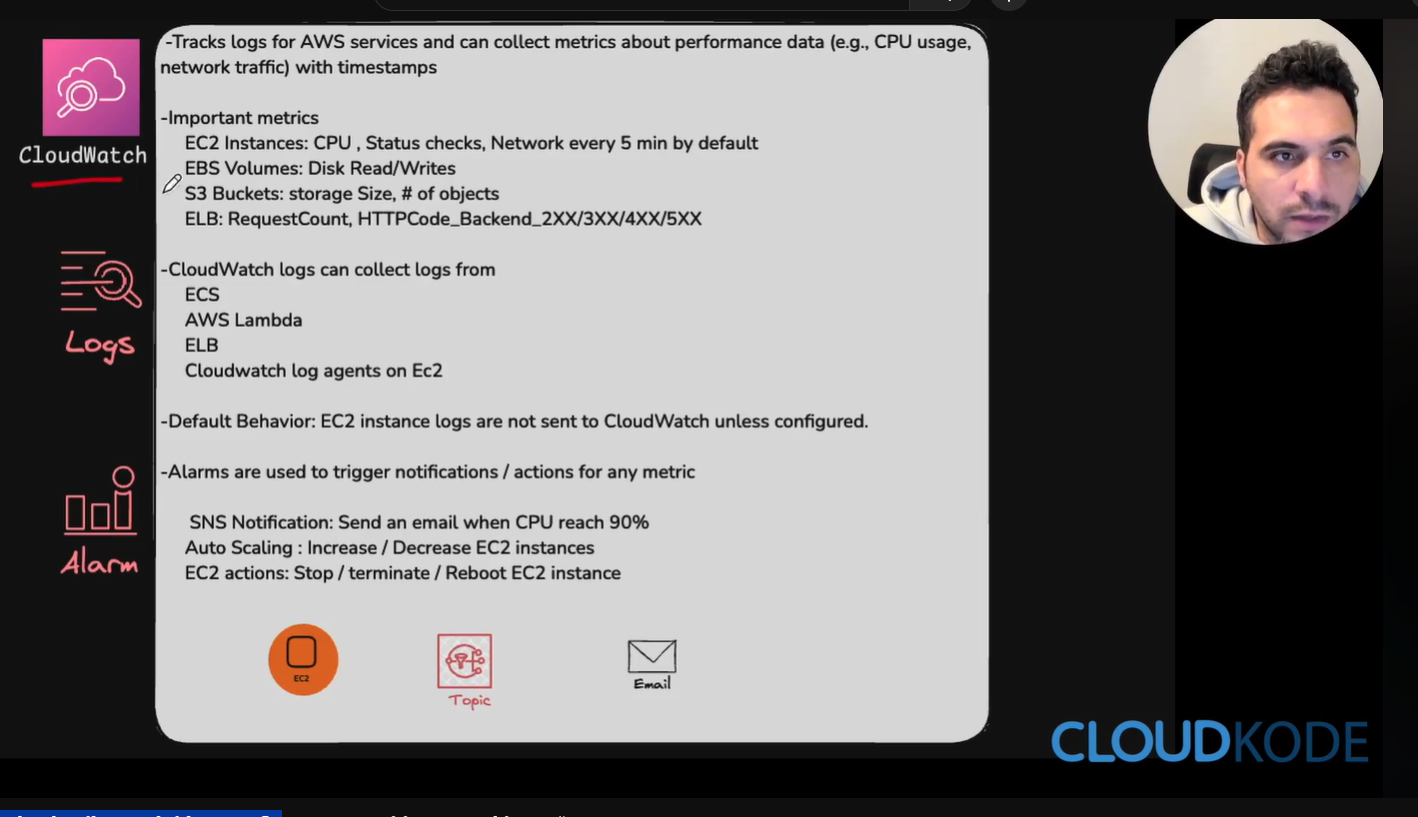

Examples:

```text
EC2 CPU utilization
RDS metrics
Lambda executions
Application errors
Network traffic
Disk metrics
Custom application metrics
Logs
```

CloudWatch primarily answers:

```text
What is happening with my resources right now?
```

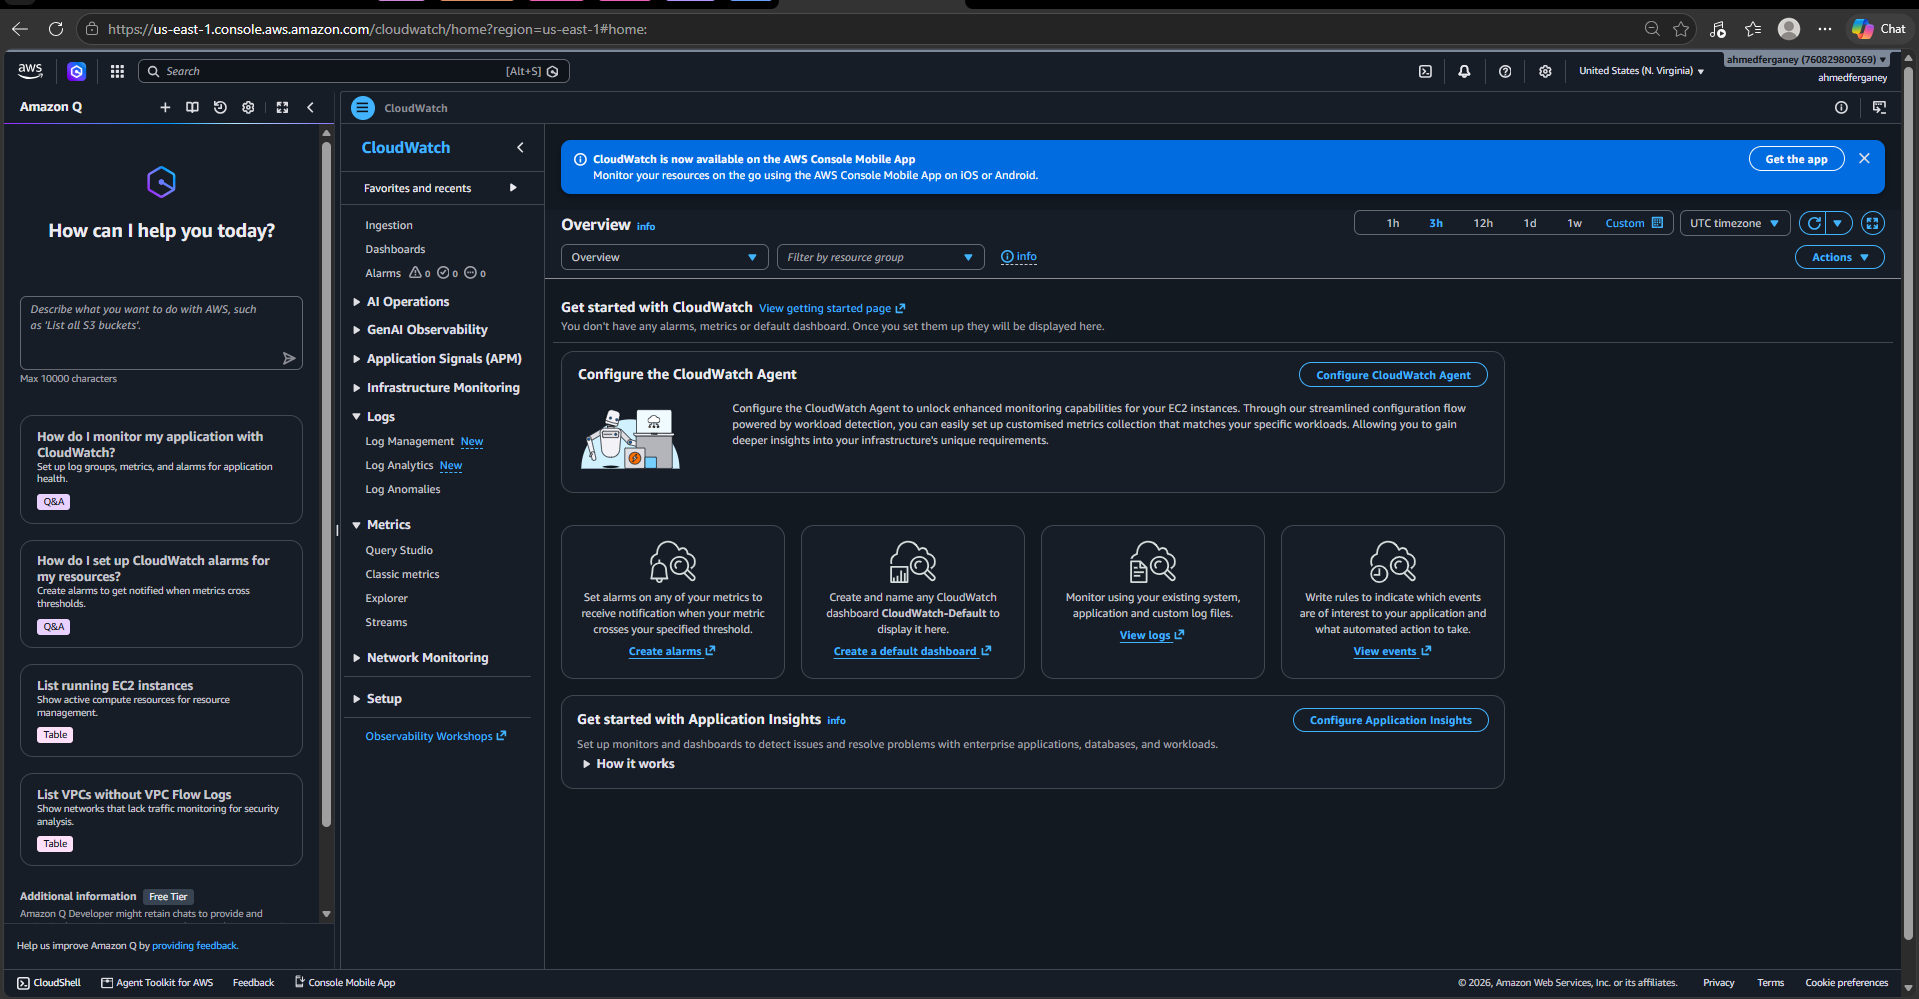

---

## 8.16 CloudWatch Metrics

A **metric** is a numerical measurement collected over time.

Example:

```text
EC2 CPUUtilization
```

Possible values:

```text
10%
25%
48%
80%
95%
```

CloudWatch can display these values in graphs.

Example:

```text
CPU Utilization

100% |
 80% |            *
 60% |       *    *
 40% |    *  *    *
 20% | *  *  *    *
  0% +----------------
      Time
```

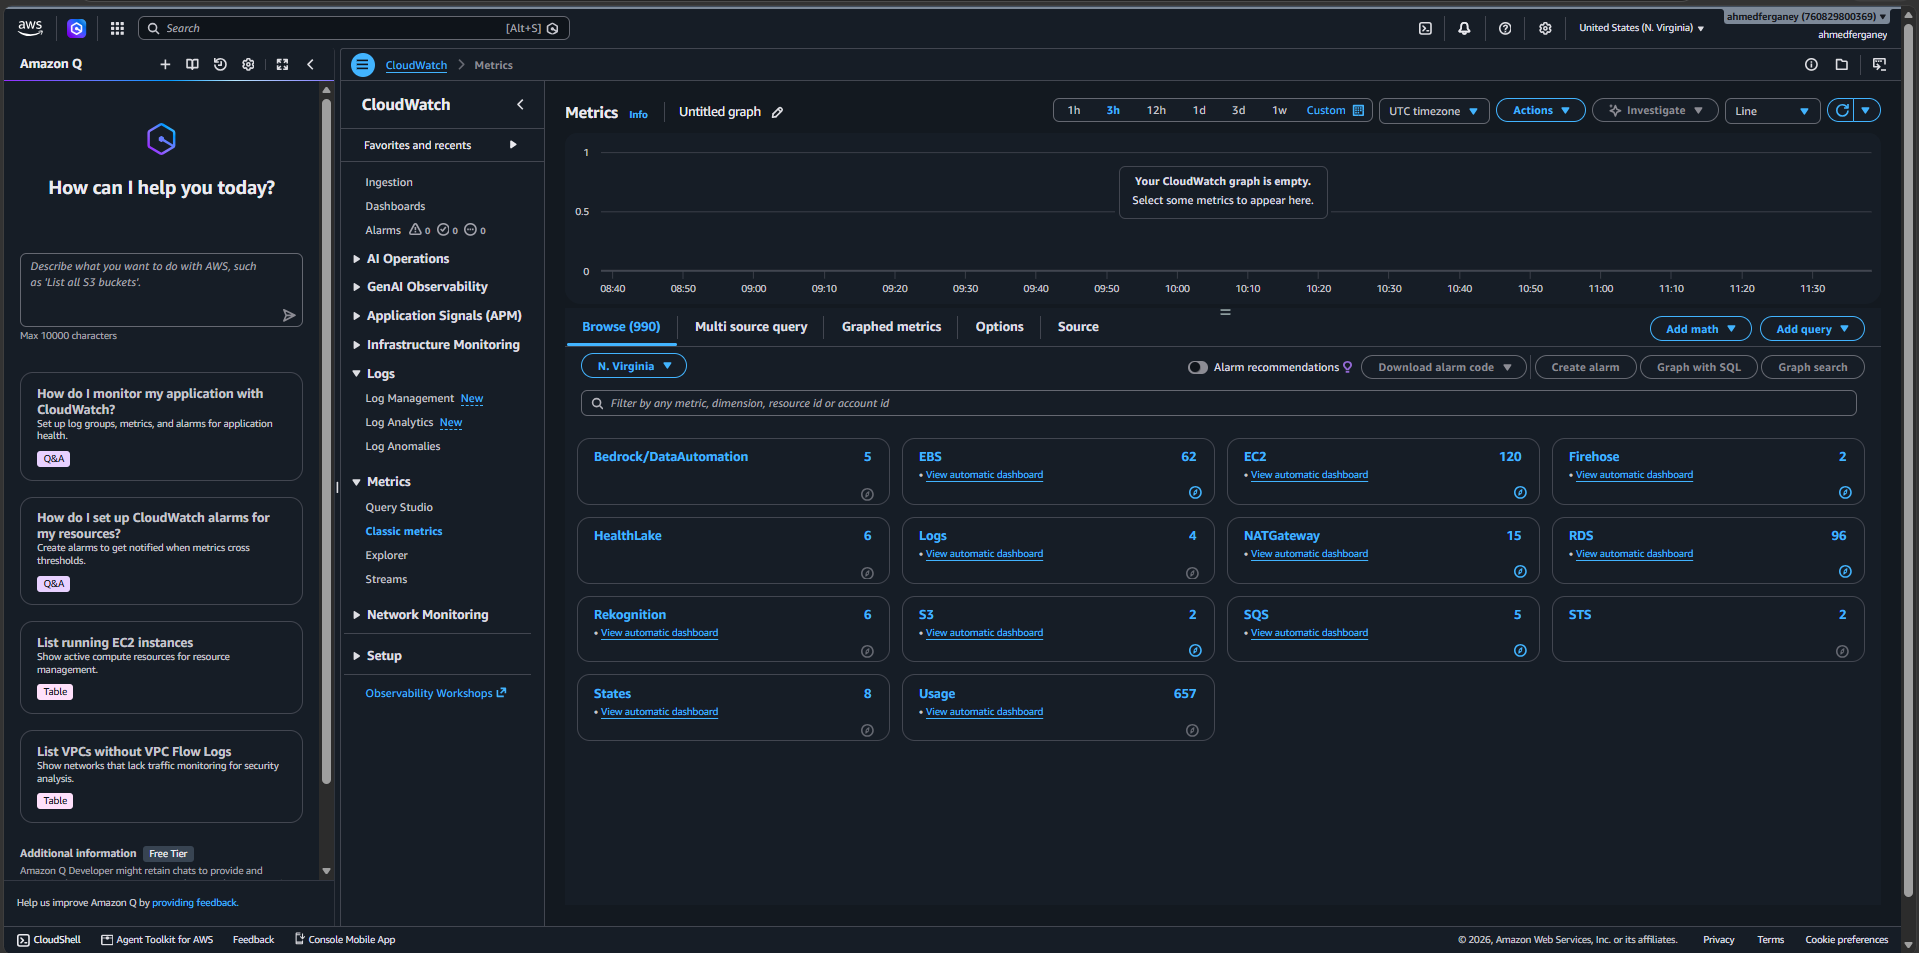

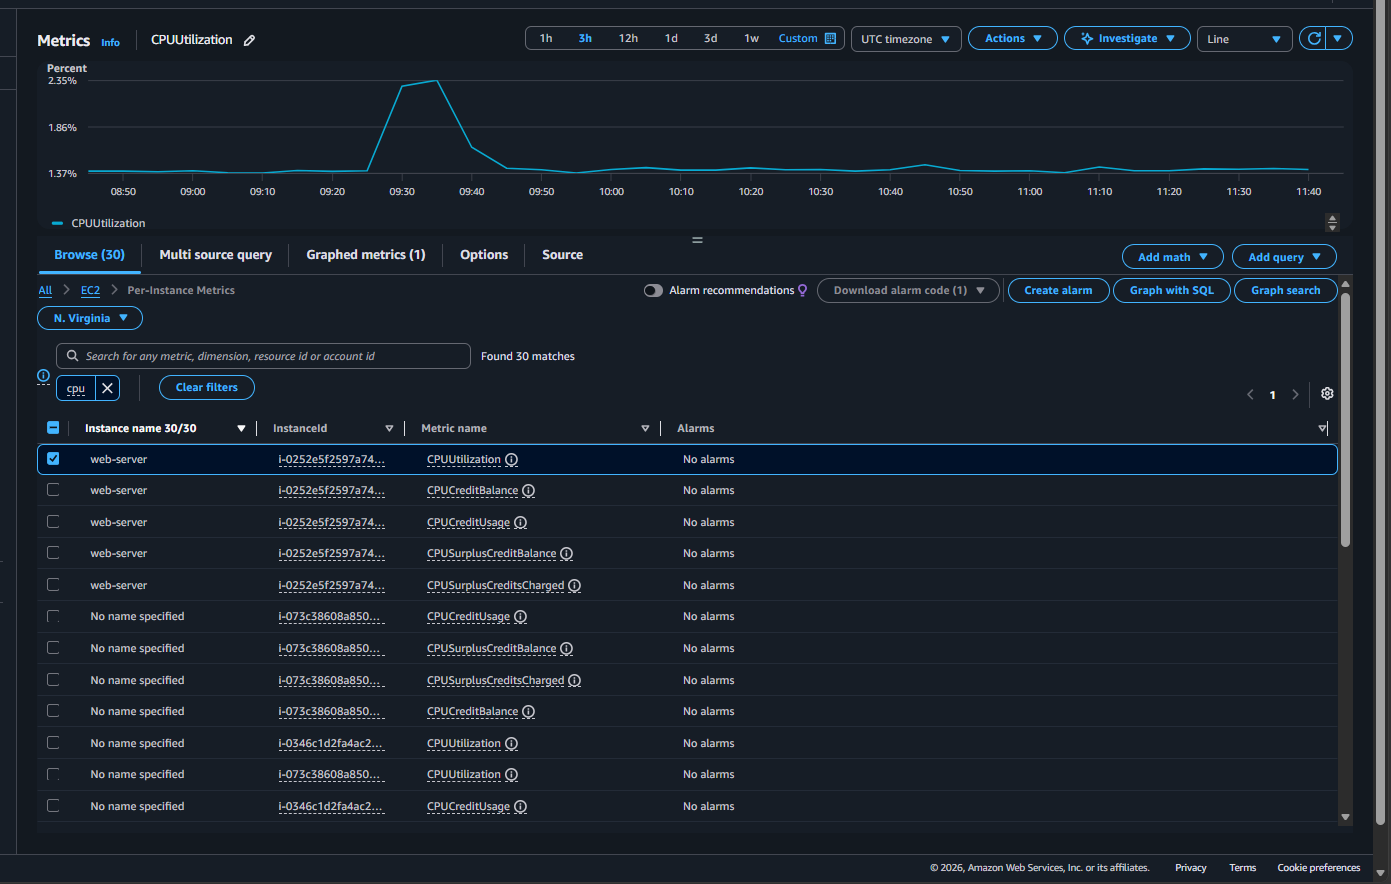

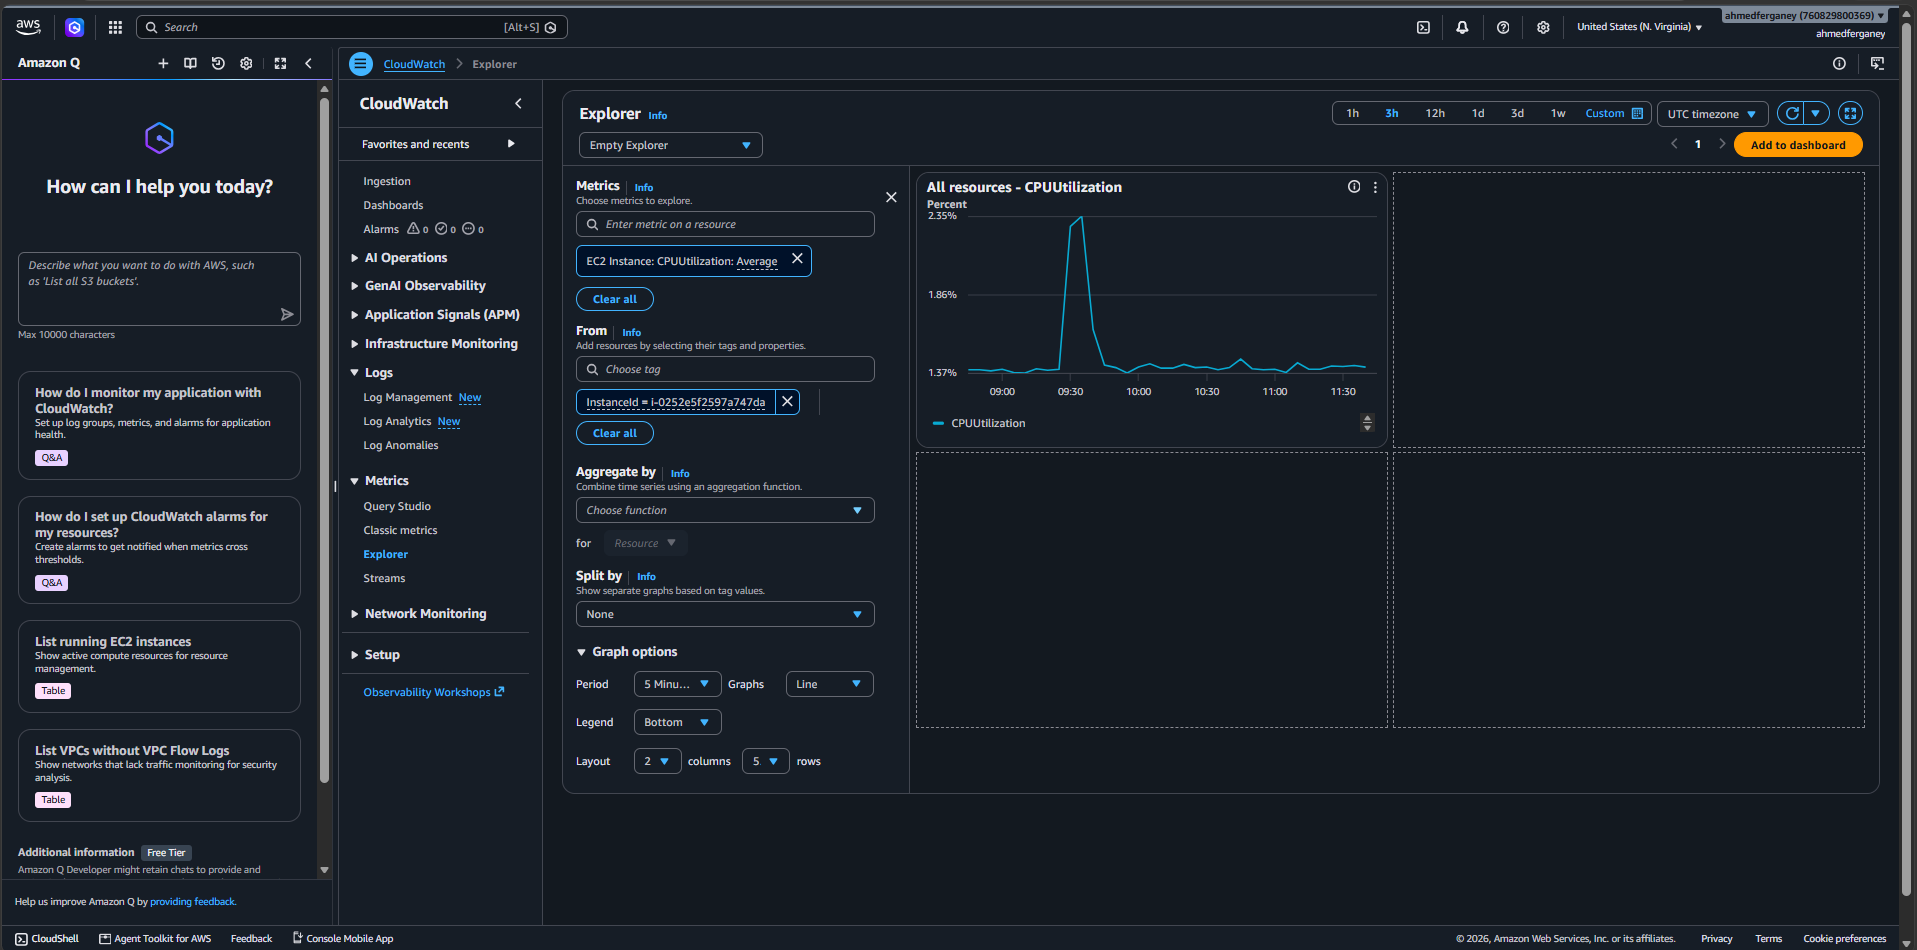

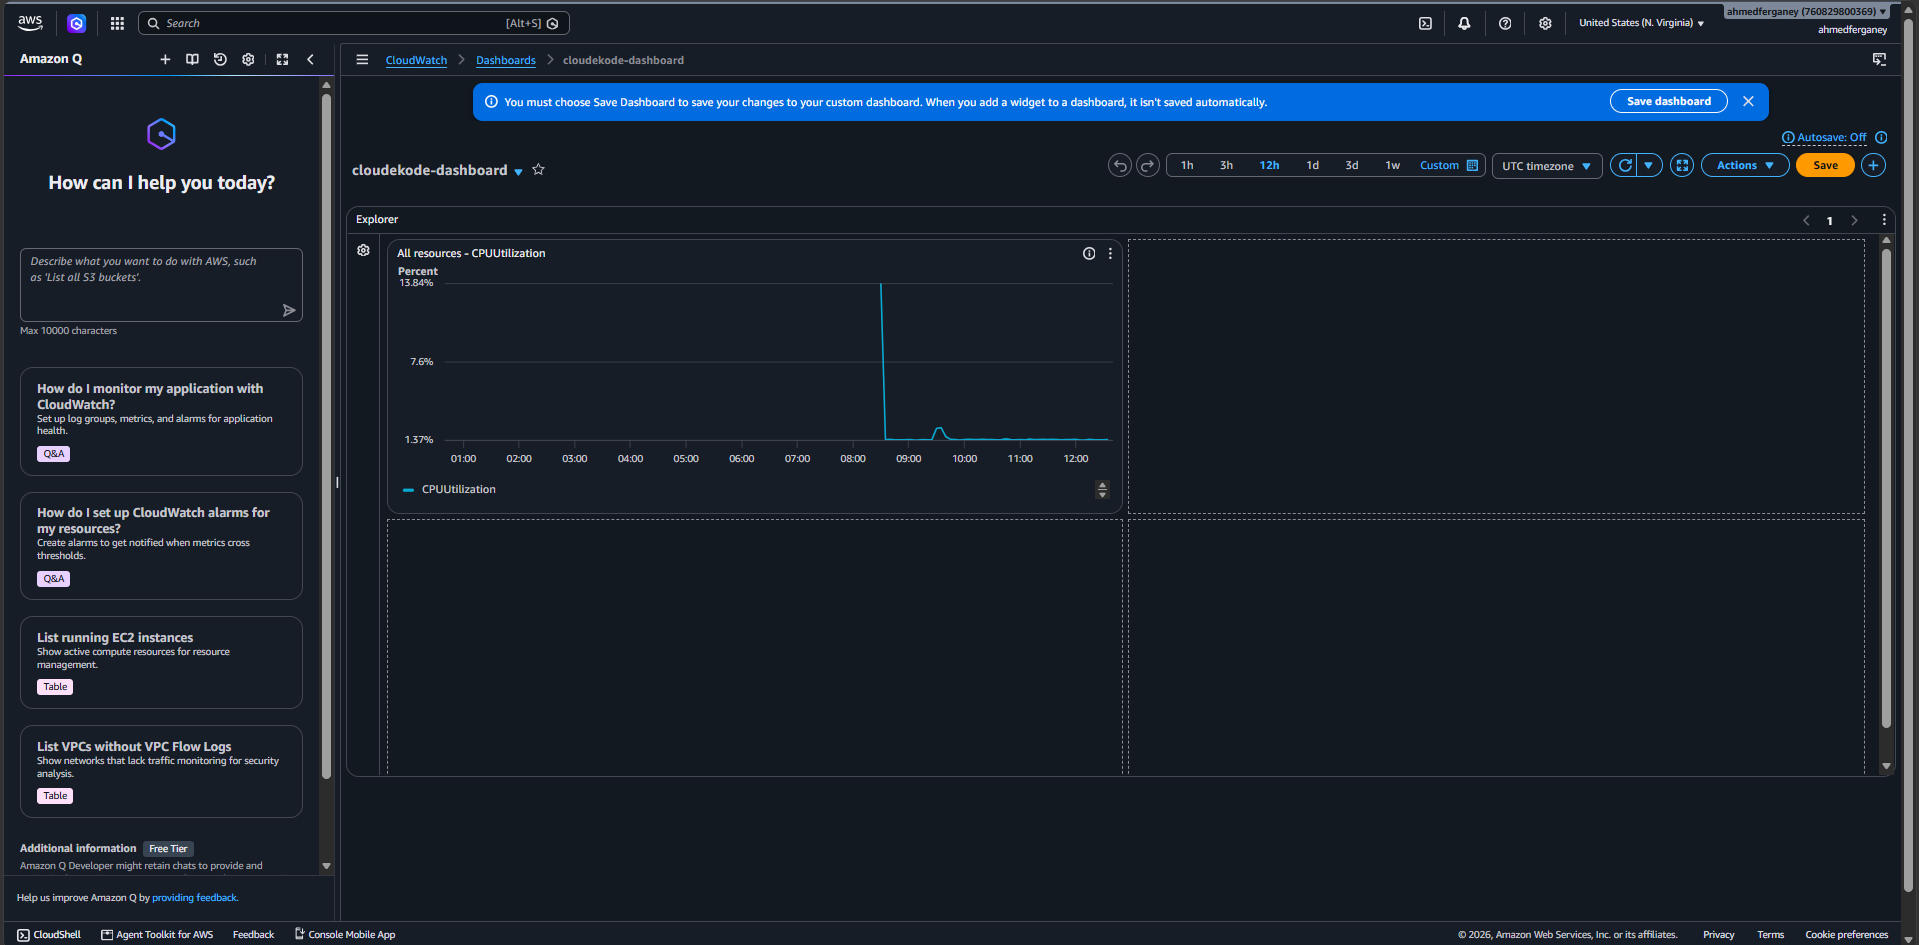

---

## 8.17 Common CloudWatch Metrics

Examples include:

```text
EC2
CPUUtilization

RDS
DatabaseConnections

Lambda
Invocations
Errors
Duration

Load Balancer
RequestCount
TargetResponseTime
```

Applications can also publish:

```text
Custom Metrics
```

Example:

```text
NumberOfOrders
FailedPayments
ActiveUsers
```

---

## 8.18 CloudWatch Logs

CloudWatch can collect application and system logs.

Example:

```text
EC2 Application
     |
     v
CloudWatch Logs
```

Possible log messages:

```text
INFO User logged in
ERROR Database connection failed
WARN CPU usage increasing
```

Logs are organized using:

```text
Log Groups
    |
    v
Log Streams
```

Example:

```text
/application

   ├── server-1
   ├── server-2
   └── server-3
```

---

## 8.19 CloudWatch Alarms

A **CloudWatch Alarm** monitors a metric and performs an action when a threshold is reached.

Example:

```text
EC2 CPU
   |
   v
CloudWatch
   |
CPU > 80%
   |
   v
Alarm
```

Possible actions:

```text
Send SNS notification
Trigger Auto Scaling action
Perform supported automated actions
```

Example:

```text
CPUUtilization > 80%
        |
        v
CloudWatch Alarm
        |
        v
SNS
        |
        v
Email Administrator
```

---

## 8.20 CloudWatch Dashboard

CloudWatch Dashboards provide visual monitoring.

Example:

```text
+-----------------------------------+
| AWS Production Dashboard          |
+-----------------------------------+
| CPU Utilization                   |
| Memory                            |
| Request Count                     |
| Errors                            |
| Database Connections              |
+-----------------------------------+
```

A dashboard can combine multiple metrics into one monitoring view.

---

## 8.21 CloudWatch Example

Imagine an EC2 server running a web application.

```text
EC2
 |
 +---- CPU
 |
 +---- Logs
 |
 +---- Network
 |
 +---- Application Metrics
 |
 v
CloudWatch
 |
 +---- Dashboard
 |
 +---- Alarm
 |
 +---- Logs
```

If CPU becomes too high:

```text
CPU > 80%
   |
CloudWatch Alarm
   |
SNS
   |
Email
```

---

## 8.22 AWS CloudTrail

**AWS CloudTrail** records AWS account activity and API calls.

It helps answer:

```text
Who did what?
When?
From where?
Using which AWS service?
```

For example:

```text
Who terminated this EC2 instance?

Who deleted this S3 bucket?

Who changed this Security Group?

Who created this IAM user?
```

CloudTrail is mainly used for:

```text
Auditing
Security investigation
Governance
Compliance
Activity tracking
```

---

## 8.23 CloudTrail Event Example

Suppose a user deletes an EC2 instance.

CloudTrail can record information such as:

```text
User:
Ahmed

Action:
TerminateInstances

Service:
EC2

Time:
10:20 AM

Source IP:
x.x.x.x
```

Conceptually:

```text
User
 |
AWS API Call
 |
EC2
 |
CloudTrail records the event
```

---

## 8.24 CloudTrail Records API Activity

Most activities performed through:

```text
AWS Console
AWS CLI
AWS SDK
AWS API
```

ultimately generate API activity.

CloudTrail can record that activity.

Example:

```text
AWS Console
     |
Terminate EC2
     |
AWS API
     |
CloudTrail
     |
Audit Record
```

---

## 8.25 CloudTrail Use Case

Suppose an S3 bucket suddenly becomes publicly accessible.

The security team wants to know who changed it.

They can investigate CloudTrail:

```text
CloudTrail
   |
Search API Activity
   |
Find:
PutBucketPolicy
   |
Identify User
```

---

## 8.26 CloudWatch vs CloudTrail

These two services are commonly confused.

### CloudWatch

Answers:

```text
How is my resource performing?
```

Examples:

```text
CPU = 95%
Application errors = 20
Lambda failed 5 times
```

### CloudTrail

Answers:

```text
Who performed this AWS action?
```

Examples:

```text
Ahmed terminated EC2

Admin changed IAM policy

User deleted S3 bucket
```

Easy way to remember:

```text
CloudWatch
=
Watch performance
```

```text
CloudTrail
=
Track activity trail
```

---

## 8.27 Amazon EventBridge

**Amazon EventBridge** is a serverless event bus service.

It allows applications and AWS services to react automatically when events occur.

Example:

```text
Event
  |
  v
EventBridge
  |
  v
Rule
  |
  v
Target
```

Possible targets include:

```text
Lambda
SQS
SNS
Step Functions
Other AWS services
```

---

## 8.28 What Is an Event?

An event represents something that happened.

Examples:

```text
EC2 instance changed state

New order created

Application deployment completed

S3-related event

Scheduled time reached
```

EventBridge can detect or receive events and route them to targets.

---

## 8.29 EventBridge Architecture

Example:

```text
EC2
 |
Instance Stopped
 |
 v
EventBridge
 |
Rule
 |
 v
Lambda
```

Another example:

```text
Application
    |
Order Created
    |
    v
EventBridge
    |
    +------> Lambda
    |
    +------> SQS
    |
    +------> Step Functions
```

---

## 8.30 EventBridge Rules

A rule defines:

```text
When this event happens
        |
        v
Send it to this target
```

Example:

```text
Event:
EC2 instance stopped

Target:
SNS Topic
```

Architecture:

```text
EC2 Stopped
    |
    v
EventBridge
    |
    v
SNS
    |
    v
Email Administrator
```

---

## 8.31 EventBridge Scheduled Events

EventBridge can also run actions on a schedule.

Example:

```text
Every day at 10 PM
       |
       v
EventBridge
       |
       v
Lambda
```

Example use case:

```text
Stop development EC2 instances every night
```

Architecture:

```text
10 PM
 |
EventBridge
 |
Lambda
 |
Stop EC2
```

---

## 8.32 EventBridge Event Bus

An EventBridge Event Bus receives events.

Conceptually:

```text
Event Sources
     |
     v
Event Bus
     |
     +------> Rule A → Lambda
     |
     +------> Rule B → SQS
     |
     +------> Rule C → SNS
```

This allows applications to use an **event-driven architecture**.

---

## 8.33 AWS Config

**AWS Config** continuously records and evaluates the configuration of AWS resources.

It helps answer:

```text
What configuration did this resource have?

How did its configuration change?

Is this resource compliant with my organization's rules?
```

AWS Config focuses on:

```text
Resource configuration
Configuration history
Compliance
Governance
```

---

## 8.34 AWS Config Example

Suppose a Security Group originally allows:

```text
SSH Port 22
Source:
10.0.0.0/16
```

Someone changes it to:

```text
SSH Port 22
Source:
0.0.0.0/0
```

AWS Config can record that configuration change.

Example:

```text
Before

SSH 22
10.0.0.0/16

        |
        v

After

SSH 22
0.0.0.0/0
```

AWS Config can help identify:

```text
When configuration changed
What the previous configuration was
Whether the resource is compliant
```

---

## 8.35 AWS Config Rules

A **Config Rule** checks whether AWS resources comply with a required condition.

Example rule:

```text
S3 buckets must not be publicly accessible
```

AWS Config evaluates:

```text
S3 Bucket
    |
    v
Config Rule
    |
    +------> COMPLIANT
    |
    └------> NON_COMPLIANT
```

---

## 8.36 AWS Config Compliance Example

Suppose your company requires:

```text
All EBS volumes must be encrypted
```

AWS Config can evaluate resources:

```text
EBS-1
Encrypted
→ COMPLIANT

EBS-2
Not encrypted
→ NON_COMPLIANT
```

This is useful for:

```text
Security
Compliance
Governance
Auditing
```

---

## 8.37 CloudTrail vs AWS Config

These services solve different problems.

### CloudTrail

Records:

```text
Who performed an action?
```

Example:

```text
Ahmed changed the Security Group.
```

### AWS Config

Records:

```text
How did the resource configuration change?
```

Example:

```text
SSH source changed:

10.0.0.0/16
        ↓
0.0.0.0/0
```

So:

```text
CloudTrail
=
Who changed it?
```

```text
AWS Config
=
What changed?
```

---

## 8.38 CloudWatch vs CloudTrail vs Config

A very important distinction is:

### CloudWatch

```text
What is happening operationally?
```

Example:

```text
CPU = 95%
```

### CloudTrail

```text
Who performed an AWS API action?
```

Example:

```text
User terminated EC2
```

### AWS Config

```text
What changed in the resource configuration?
```

Example:

```text
Security Group changed from private SSH access
to public SSH access
```

Easy memory:

```text
CloudWatch
=
Performance
```

```text
CloudTrail
=
Activity
```

```text
Config
=
Configuration
```

---

## 8.39 EventBridge vs SNS

Both services can distribute events, but their primary roles differ.

### SNS

Designed mainly for:

```text
Pub/Sub notifications
One-to-many messaging
```

Example:

```text
Application
   |
SNS
   |
   +---- Email
   +---- SMS
   +---- SQS
```

### EventBridge

Designed mainly for:

```text
Event routing
Event filtering
Event-driven automation
```

Example:

```text
AWS Service Event
       |
EventBridge
       |
Rule
       |
Lambda
```

---

## 8.40 SQS vs SNS vs EventBridge

A simple comparison:

| Service | Main Purpose | Pattern |
|---|---|---|
| SQS | Queue messages | Producer → Queue → Consumer |
| SNS | Publish notifications | Publisher → Topic → Many subscribers |
| EventBridge | Route events | Event → Rule → Target |

Remember:

```text
SQS
=
Queue
```

```text
SNS
=
Notification / Fan-Out
```

```text
EventBridge
=
Event Router
```

---

## 8.41 Practical Architecture Using All Services

Consider an online shopping application.

```text
Customer
   |
   v
Web Application
   |
   v
Order Created
```

The application sends processing work to SQS:

```text
Application
     |
     v
SQS
     |
     v
Order Worker
```

It publishes notifications using SNS:

```text
Order Completed
      |
      v
SNS
      |
      +------> Email
      |
      +------> SMS
```

CloudWatch monitors the system:

```text
EC2 / Lambda / Application
          |
          v
      CloudWatch
          |
    Metrics + Logs
```

CloudTrail records administrator/API activity:

```text
AWS User
   |
API Action
   |
CloudTrail
```

EventBridge reacts to events:

```text
EC2 State Change
      |
      v
EventBridge
      |
      v
Lambda
```

AWS Config checks resource compliance:

```text
AWS Resources
      |
      v
AWS Config
      |
      v
Compliance Rules
```

---

## 8.42 Complete Architecture

```text
                        Users
                          |
                          v
                   Web Application
                          |
               +----------+----------+
               |                     |
               v                     v
              SQS                   SNS
               |                     |
               v               +-----+-----+
            Workers            |           |
                               v           v
                             Email        SMS


AWS Resources
     |
     +--------------------------+
     |                          |
     v                          v
CloudWatch                  CloudTrail
     |                          |
Metrics / Logs              API Activity
     |
     v
Alarms


AWS Events
     |
     v
EventBridge
     |
Rules
     |
     +------> Lambda
     +------> SNS
     +------> SQS


AWS Resource Configuration
          |
          v
      AWS Config
          |
          v
Compliance Evaluation
```

---

## 8.43 Exam Shortcuts

If the question says:

```text
Decouple applications
Message queue
Buffer workloads
Consumer processes messages later
```

Think:

```text
Amazon SQS
```

---

If the question says:

```text
Send notification
Email
SMS
One message to many subscribers
Pub/Sub
```

Think:

```text
Amazon SNS
```

---

If the question says:

```text
CPU utilization
Metrics
Logs
Alarms
Application monitoring
```

Think:

```text
Amazon CloudWatch
```

---

If the question says:

```text
Who deleted this resource?

Who changed this IAM policy?

API history

User activity
```

Think:

```text
AWS CloudTrail
```

---

If the question says:

```text
When an event occurs, automatically trigger an action

Event-driven architecture

Scheduled event

Route AWS events
```

Think:

```text
Amazon EventBridge
```

---

If the question says:

```text
Track resource configuration

Configuration history

Compliance rules

Detect non-compliant resources
```

Think:

```text
AWS Config
```

---

## 8.44 Final Comparison

| Service | Main Question It Answers |
|---|---|
| Amazon SQS | Where can I queue work until a consumer is ready? |
| Amazon SNS | How can I send one message to many subscribers? |
| CloudWatch | How is my system performing? |
| CloudTrail | Who performed this AWS API action? |
| EventBridge | What should happen when this event occurs? |
| AWS Config | How is this resource configured, and is it compliant? |

---

## 8.45 Easy Mental Model

```text
SQS
=
Wait in line
```

```text
SNS
=
Tell everyone
```

```text
CloudWatch
=
Watch the system
```

```text
CloudTrail
=
Track what users did
```

```text
EventBridge
=
When this happens, do that
```

```text
AWS Config
=
Check how resources are configured
```

---

## 8.46 Final Summary

The six services can be remembered as:

```text
Application Messaging

SQS
→ Queue

SNS
→ Notifications
```

```text
Monitoring and Auditing

CloudWatch
→ Performance, metrics, logs, alarms

CloudTrail
→ API activity and user actions
```

```text
Automation and Governance

EventBridge
→ Event routing and automation

AWS Config
→ Configuration tracking and compliance
```

The most important distinction is:

```text
CloudWatch
=
What is happening?
```

```text
CloudTrail
=
Who did it?
```

```text
AWS Config
=
What changed in the configuration?
```

and:

```text
SQS
=
One queue for consumers
```

```text
SNS
=
One message to many subscribers
```

```text
EventBridge
=
Route events to the correct targets
```